In [2]:
import sqlite3
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

In [4]:
url = "https://share.borza.cc/"

SOURCES = {"details": "ingatlan-details.parquet", "listings": "listings.parquet"}

def load_dataset(name: str) -> pd.DataFrame:
    fp = Path('data', f"ingatlan-{name}.parquet")
    if fp.exists():
        return pd.read_parquet(fp)
    df = pd.read_parquet(url + fp.name)
    df.to_parquet(fp)
    return df

SAMPLE_SIZE_DETAILS = 100_000
SAMPLE_SIZE_LISTINGS = 100_000




details_sample = load_dataset("details").sample(SAMPLE_SIZE_DETAILS, random_state=42)
listings_sample = load_dataset("listings").sample(SAMPLE_SIZE_LISTINGS, random_state=42)

print(f"details sample:  {details_sample.shape}")
print(f"listings sample: {listings_sample.shape}")
details_sample.dtypes

details sample:  (100000, 7)
listings sample: (100000, 3)


loc          str
city         str
price      int64
m2         int64
rooms        str
balcony      str
id         int64
dtype: object

In [5]:
def measure_write_read(
    write_fn,
    read_fn,
    path: Path,
    n_repeats: int = 3,
) -> dict[str, float]:
    """Time write and read operations and return means over n_repeats runs."""
    write_times = []
    for _ in range(n_repeats):
        path.unlink(missing_ok=True)
        t0 = time.perf_counter()
        write_fn(path)
        write_times.append(time.perf_counter() - t0)

    read_times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        read_fn(path)
        read_times.append(time.perf_counter() - t0)

    return {
        "write_s": sum(write_times) / n_repeats,
        "read_s": sum(read_times) / n_repeats,
        "size_mb": path.stat().st_size / 1_048_576,
    }


def benchmark_csv(df: pd.DataFrame, tmp: Path) -> dict:
    path = tmp / "data.csv"
    return {
        "format": "CSV",
        **measure_write_read(
            lambda p: df.to_csv(p, index=False),
            pd.read_csv,
            path,
        ),
    }


def benchmark_csv_gz(df: pd.DataFrame, tmp: Path) -> dict:
    path = tmp / "data.csv.gz"
    return {
        "format": "CSV (gzip)",
        **measure_write_read(
            lambda p: df.to_csv(p, index=False, compression="gzip"),
            lambda p: pd.read_csv(p, compression="gzip"),
            path,
        ),
    }


def benchmark_parquet(df: pd.DataFrame, tmp: Path, label: str = "Parquet") -> dict:
    path = tmp / f"{label}.parquet"
    return {
        "format": label,
        **measure_write_read(
            lambda p: df.to_parquet(p, index=False),
            pd.read_parquet,
            path,
        ),
    }


def benchmark_pickle(df: pd.DataFrame, tmp: Path) -> dict:
    path = tmp / "data.pkl"
    return {
        "format": "Pickle",
        **measure_write_read(
            df.to_pickle,
            pd.read_pickle,
            path,
        ),
    }


def benchmark_sqlite(df: pd.DataFrame, tmp: Path) -> dict:
    path = tmp / "data.db"

    def write_sqlite(p: Path) -> None:
        p.unlink(missing_ok=True)
        with sqlite3.connect(p) as conn:
            df.to_sql("data", conn, if_exists="replace", index=False)

    def read_sqlite(p: Path) -> pd.DataFrame:
        with sqlite3.connect(p) as conn:
            return pd.read_sql("SELECT * FROM data", conn)

    return {
        "format": "SQLite",
        **measure_write_read(write_sqlite, read_sqlite, path),
    }

In [6]:
with tempfile.TemporaryDirectory() as tmpdir_str:
    tmp = Path(tmpdir_str)
    results = pd.DataFrame(
        [
            benchmark_csv(details_sample, tmp),
            benchmark_csv_gz(details_sample, tmp),
            benchmark_parquet(details_sample, tmp),
            benchmark_pickle(details_sample, tmp),
            benchmark_sqlite(details_sample, tmp),
        ]
    ).set_index("format")

results

,write_s,read_s,size_mb
format,,,
CSV,0.128736,0.080312,6.828938
CSV (gzip),0.577440,0.089162,1.791553
Parquet,0.026135,0.006890,1.897992
Pickle,0.003531,0.001241,10.556262
SQLite,0.191514,0.161054,6.617188


In [7]:
(
    results.style.background_gradient(
        cmap="RdYlGn_r", subset=["write_s", "read_s", "size_mb"]
    )
    .format({"write_s": "{:.3f} s", "read_s": "{:.3f} s", "size_mb": "{:.2f} MB"})
    .set_caption(
        f"Serialization benchmark \u2014 {SAMPLE_SIZE_DETAILS:,} rows of ingatlan-details"
        " (mean of 3 runs)"
    )
)

,write_s,read_s,size_mb
format,,,
CSV,0.129 s,0.080 s,6.83 MB
CSV (gzip),0.577 s,0.089 s,1.79 MB
Parquet,0.026 s,0.007 s,1.90 MB
Pickle,0.004 s,0.001 s,10.56 MB
SQLite,0.192 s,0.161 s,6.62 MB


/tmp/ipykernel_7630/2013739754.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results.index, rotation=20, ha="right")
/tmp/ipykernel_7630/2013739754.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results.index, rotation=20, ha="right")
/tmp/ipykernel_7630/2013739754.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results.index, rotation=20, ha="right")


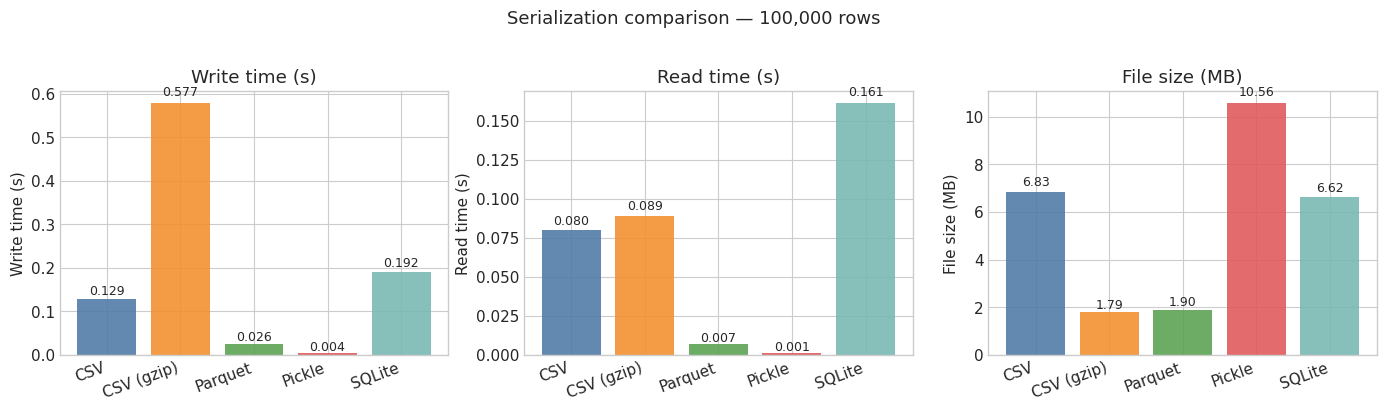

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759", "#76b7b2"]

for ax, (col, label, color_key) in zip(
    axes,
    [
        ("write_s", "Write time (s)", 0),
        ("read_s", "Read time (s)", 1),
        ("size_mb", "File size (MB)", 2),
    ],
):
    ax.bar(results.index, results[col], color=palette, alpha=0.88)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticklabels(results.index, rotation=20, ha="right")
    for bar, val in zip(ax.patches, results[col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f"{val:.3f}" if col != "size_mb" else f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.suptitle(
    f"Serialization comparison \u2014 {SAMPLE_SIZE_DETAILS:,} rows",
    y=1.02,
    fontsize=13,
)
plt.tight_layout()
plt.show()

## The Index Trap in Parquet

When you `.sample()` from a large DataFrame, the result keeps the **original row indices** — a sparse,
non-contiguous subset of 0…9M. Parquet stores the index as a column of large integers that
compress poorly compared to a dense 0…49999 range.

A simple `reset_index(drop=True)` — or passing `index=False` — fixes this.

In [9]:
print("Index type :", type(listings_sample.index).__name__)
print("Index min  :", listings_sample.index.min())
print("Index max  :", listings_sample.index.max())
is_contiguous = list(listings_sample.index) == list(range(len(listings_sample)))
print("Contiguous :", is_contiguous)
print()
print(
    "The index values span the full 0..",
    listings_sample.index.max(),
    "range but only",
    len(listings_sample),
    "slots are filled — hard to compress.",
)

Index type : Index
Index min  : 159
Index max  : 9130073
Contiguous : False

The index values span the full 0.. 9130073 range but only 100000 slots are filled — hard to compress.


In [10]:
def benchmark_parquet_with_index(df: pd.DataFrame, tmp: Path, label: str) -> dict:
    """Parquet benchmark that preserves the index (default pandas behaviour)."""
    path = tmp / f"{label}.parquet"
    return {
        "variant": label,
        **measure_write_read(
            lambda p: df.to_parquet(p),  # index=True by default
            pd.read_parquet,
            path,
        ),
    }


with tempfile.TemporaryDirectory() as tmpdir_str:
    tmp = Path(tmpdir_str)
    index_results = pd.DataFrame(
        [
            benchmark_parquet_with_index(
                listings_sample,
                tmp,
                "original index (sparse)",
            ),
            benchmark_parquet_with_index(
                listings_sample.reset_index(drop=True),
                tmp,
                "reset_index() (dense 0..N)",
            ),
            benchmark_parquet_with_index(
                listings_sample.reset_index(drop=True),
                tmp,
                "index=False (no index stored)",
            ),
        ]
    ).set_index("variant")

# override last row: index=False version
with tempfile.TemporaryDirectory() as tmpdir_str:
    tmp = Path(tmpdir_str)
    path = tmp / "noindex.parquet"
    r = measure_write_read(
        lambda p: listings_sample.to_parquet(p, index=False),
        pd.read_parquet,
        path,
    )
    index_results.loc["index=False (no index stored)", :] = r

index_results

,write_s,read_s,size_mb
variant,,,
original index (sparse),0.016575,0.003511,1.509044
reset_index() (dense 0..N),0.007539,0.002224,0.821124
index=False (no index stored),0.007469,0.002079,0.820710


In [11]:
(
    index_results.style.background_gradient(
        cmap="RdYlGn_r", subset=["write_s", "read_s", "size_mb"]
    )
    .format({"write_s": "{:.3f} s", "read_s": "{:.3f} s", "size_mb": "{:.2f} MB"})
    .set_caption(
        f"Parquet index benchmark \u2014 {SAMPLE_SIZE_LISTINGS:,} rows of ingatlan-listings"
    )
)

,write_s,read_s,size_mb
variant,,,
original index (sparse),0.017 s,0.004 s,1.51 MB
reset_index() (dense 0..N),0.008 s,0.002 s,0.82 MB
index=False (no index stored),0.007 s,0.002 s,0.82 MB


/tmp/ipykernel_7630/4127484140.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha="right")
/tmp/ipykernel_7630/4127484140.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha="right")
/tmp/ipykernel_7630/4127484140.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha="right")


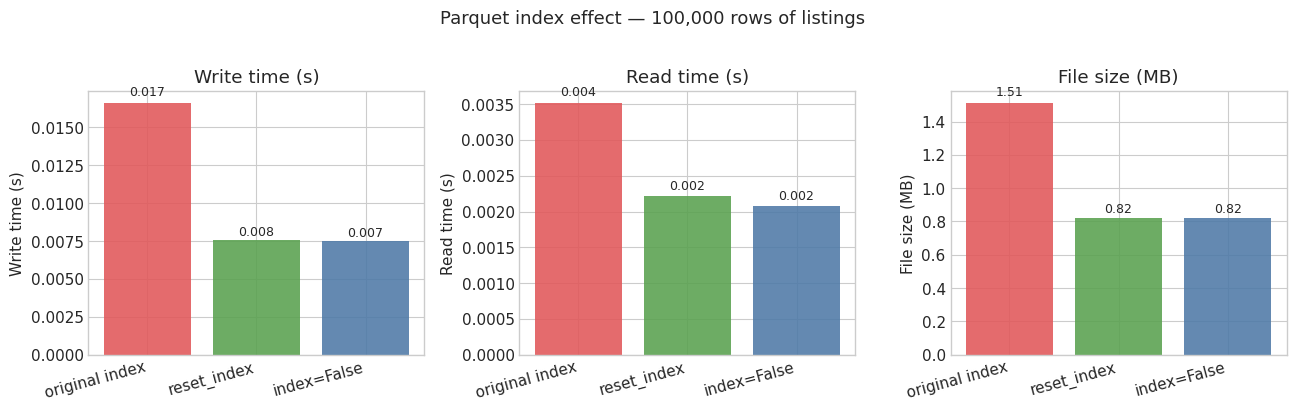

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["#e15759", "#59a14f", "#4e79a7"]
labels = [v.split("(")[0].strip() for v in index_results.index]

for ax, (col, ylabel) in zip(
    axes,
    [
        ("write_s", "Write time (s)"),
        ("read_s", "Read time (s)"),
        ("size_mb", "File size (MB)"),
    ],
):
    bars = ax.bar(labels, index_results[col], color=colors, alpha=0.88)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xticklabels(labels, rotation=15, ha="right")
    for bar, val in zip(bars, index_results[col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f"{val:.3f}" if col != "size_mb" else f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.suptitle(
    f"Parquet index effect \u2014 {SAMPLE_SIZE_LISTINGS:,} rows of listings",
    y=1.02,
    fontsize=13,
)
plt.tight_layout()
plt.show()